In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

In [52]:
# create a small synthetic dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy': [0, 1, 0, 1, 0, 1, 0, 1],
    'Play': [1, 0, 1, 1, 0, 0, 1, 0]
}

df_synthetic = pd.DataFrame(data)

df_synthetic.head()

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0


In [53]:
df_synthetic['Weather_num'] = df_synthetic['Weather'].map({'Sunny': 1, 'Rainy': 0})


In [54]:
X = df_synthetic[['Weather_num', 'Windy']]
y = df_synthetic['Play']

In [55]:
tree_syn = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(X, y)
tree_syn 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

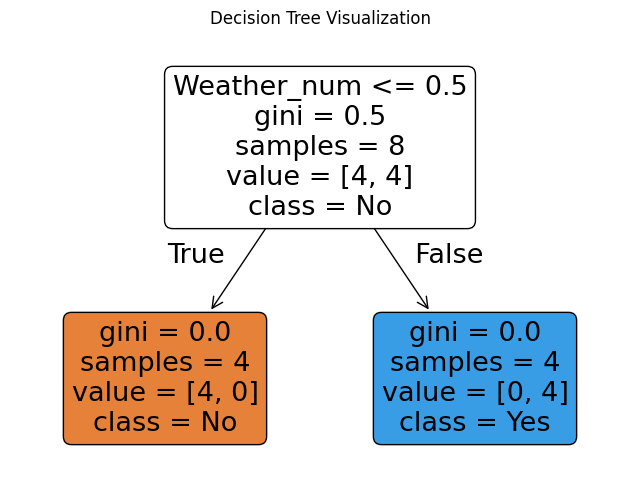

In [56]:
# Visualize the tree
plt.figure(figsize=(8, 6))
plot_tree(
    tree_syn, 
    feature_names=['Weather_num', 'Windy'], 
    class_names=['No', 'Yes'], 
    filled=True,
    rounded=True
    
)
plt.title("Decision Tree Visualization")
plt.show()

# Overfitting and Pruning of Decision Trees

In [57]:
# Exampls: Sunny (1) and Not Windy (0) Play
example_1 = pd.DataFrame([[1, 0]], columns=['Weather_num', 'Windy'])
prediction_1 = tree_syn.predict(example_1)
print(f"Prediction for Sunny and Not Windy: {'Play' if prediction_1[0] == 1 else 'No Play'}")

# Example: Rainy (0) and Windy (1)
example_2 = pd.DataFrame([[0, 1]], columns=['Weather_num', 'Windy'])
prediction_2 = tree_syn.predict(example_2)
print(f"Prediction for Rainy and Windy: {'Play' if prediction_2[0] == 1 else 'No Play'}")

Prediction for Sunny and Not Windy: Play
Prediction for Rainy and Windy: No Play


In [58]:
from sklearn.datasets import make_classification

X_big, y_big = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=2,
    n_classes=2,
    random_state=42
)


X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y_big, test_size=0.3, random_state=42
)

X_train_big.shape, y_train_big.shape, X_test_big.shape, y_test_big.shape

((350, 5), (350,), (150, 5), (150,))

In [59]:
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_big, y_train_big)


prune_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
prune_tree.fit(X_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_prune = prune_tree.predict(X_train_big)
y_test_pred_prune = prune_tree.predict(X_test_big)

print("Deep Tree Performance:") 
print("Training Accuracy:", round(accuracy_score(y_train_big, y_train_pred_deep), 3))
print("Testing Accuracy:", round(accuracy_score(y_test_big, y_test_pred_deep), 3))

print("\nPruned Tree Performance:") 
print("Training Accuracy:", round(accuracy_score(y_train_big, y_train_pred_prune), 3))
print("Testing Accuracy:", round(accuracy_score(y_test_big, y_test_pred_prune), 3))

print("\nDeep tree is Overfitted:", round(accuracy_score(y_train_big, y_train_pred_deep), 3) > round(accuracy_score(y_test_big, y_test_pred_deep), 3))


Deep Tree Performance:
Training Accuracy: 1.0
Testing Accuracy: 0.84

Pruned Tree Performance:
Training Accuracy: 0.954
Testing Accuracy: 0.92

Deep tree is Overfitted: True


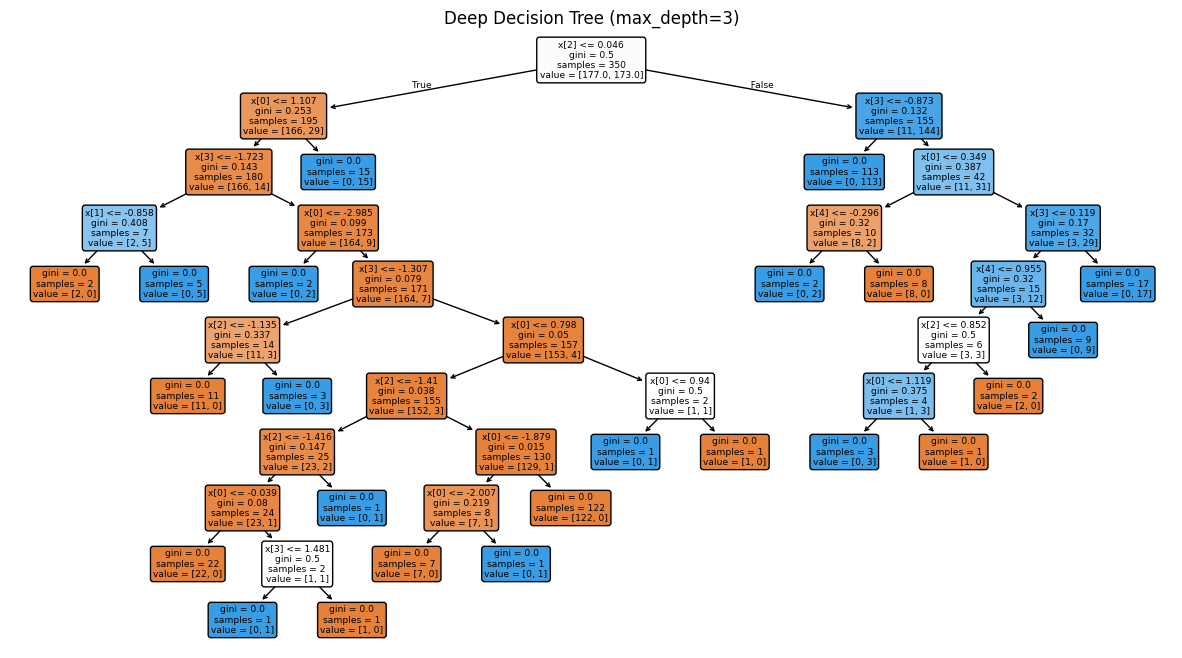

In [60]:
# Plot deep tree
plt.figure(figsize=(15, 8))
plot_tree(
    deep_tree,
    filled=True,
    rounded=True,
    # max_depth=3
)
plt.title("Deep Decision Tree (max_depth=3)")
plt.show()

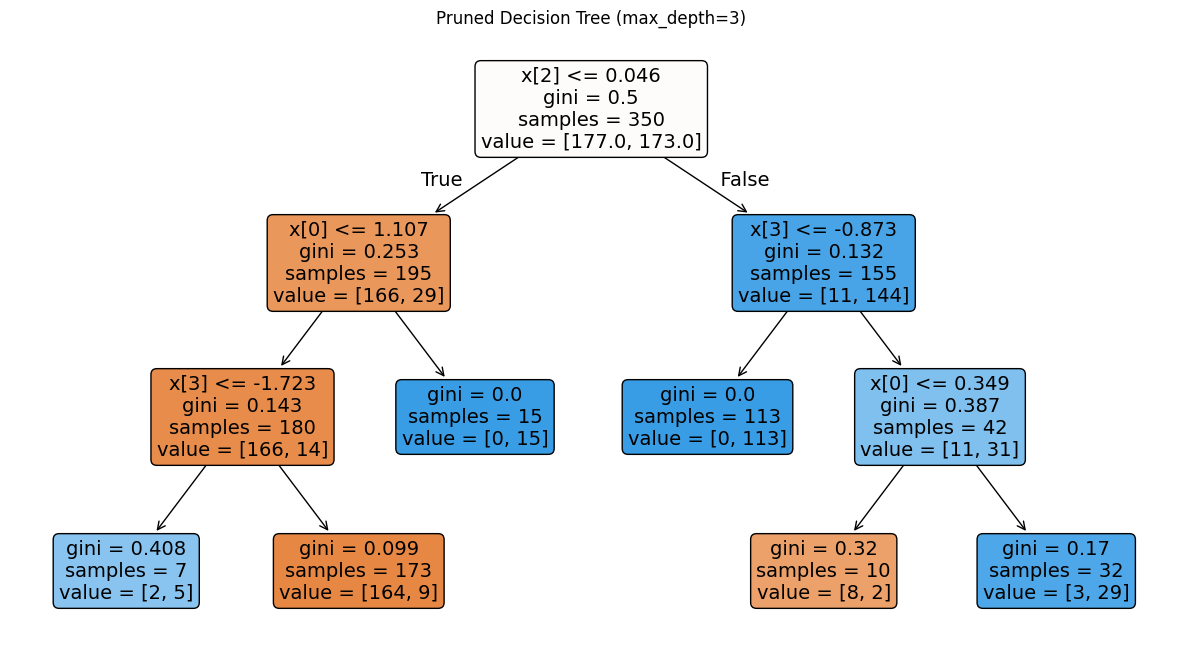

In [61]:
# Plot pruned tree

plt.figure(figsize=(15, 8))
plot_tree(
    prune_tree,
    filled=True,
    rounded=True,
    # max_depth=3
)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

# Evaluating the Decision Tree (Accuracy, Precision, Recall, F1-Score) 

In [62]:
# Creating a toy heart disease dataset
np.random.seed(42)
n_samples = 600

age = np.random.randint(30, 80, size = n_samples)
chol = np.random.randint(150, 300, size = n_samples)
thalach = np.random.randint(90, 200, size = n_samples)

# create a rule based probability of heart disease
risk_score = 0.03 * (age - 40) + 0.02 * (chol - 200) - 0.02 * (thalach - 140)

# Sigmoid function to convert risk score to probability
prob = 1 / (1 + np.exp(-0.05 * risk_score))
target = (prob > np.median(prob)).astype(int)


df_heart = pd.DataFrame({
    'Age': age,
    'Cholesterol': chol,
    'MaxHR': thalach,
    'HeartDisease': target
})

df_heart.head(10)

,Age,Cholesterol,MaxHR,HeartDisease
0,68,211,108,1
1,58,233,125,1
2,44,261,118,1
3,72,235,149,1
4,37,290,171,1
5,50,168,91,0
6,68,249,90,1
7,48,289,136,1
8,52,296,158,1
9,40,225,109,1


In [63]:
# Train-test split
X_heart = df_heart[['Age', 'Cholesterol', 'MaxHR']]
y_heart = df_heart['HeartDisease']

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

tree_heart = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_heart.fit(X_train_heart, y_train_heart)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [64]:
# Predictions
y_pred_heart = tree_heart.predict(X_test_heart)

# confusion matrix
cm = confusion_matrix(y_test_heart, y_pred_heart)
print(cm)

[[49 10]
 [ 6 55]]


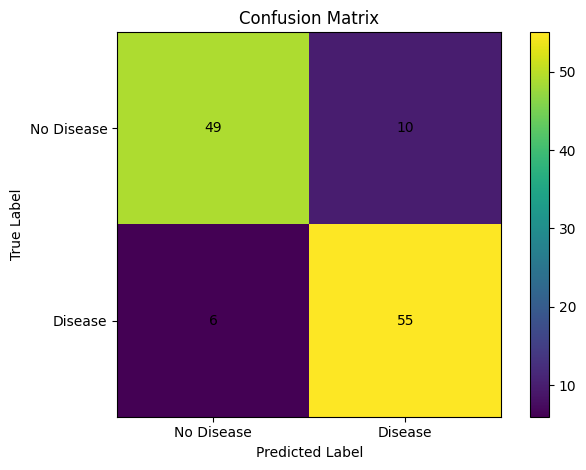

In [65]:
# Plot of confusion matrix
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

# Show all ticks and label them with the respective list entries
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_yticklabels(['No Disease', 'Disease'])

# Loop over data dimensions and create text annotations.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
        
fig.tight_layout()
plt.colorbar(im)
plt.show()

# Accuracy, Precision, Recall, F1

Accuracy:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
Precision Score: 
$$Precision = \frac{TP}{TP + FP}$$
Recall Score:
$$Recall = \frac{TP}{TP + FN}$$
F1 Score:
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [66]:
# score
acc = accuracy_score(y_test_heart, y_pred_heart)
prec = precision_score(y_test_heart, y_pred_heart)
recall = recall_score(y_test_heart, y_pred_heart)
f1 = f1_score(y_test_heart, y_pred_heart)

print("Accuracy:", round(acc, 3))
print("Precision:", round(prec, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.867
Precision: 0.846
Recall: 0.902
F1 Score: 0.873




- Is this model missing many disease cases? (Recall)
- Is this model predicting many false positives? (Precision)
- Does F1 look balanced? (F1 Score)
  
Answers: 
- No, the recall is 0.902 which means that the model is correctly identifying 90.2% of the disease cases.
- No, the precision is 0.846 which means that the model is correctly predicting 84.6% of the positive cases.
- Yes, the F1 score is 0.873 which indicates a good balance between precision and recall.

# ROC Curve, AUC, and Threshold Interpretation

ROC: Receiver Operating Characteristic Curve
- A graphical representation of the performance of a binary classifier as its discrimination threshold is varied.
- Plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.
- TPR (Recall) = TP / (TP + FN)
- FPR = FP / (FP + TN)



In [67]:
y_proba_heart = tree_heart.predict_proba(X_test_heart)[:, 1]
y_proba_heart[:10]

array([0.00862069, 1.        , 1.        , 0.00862069, 0.76923077,
       0.        , 0.        , 0.00862069, 0.76923077, 0.88235294])

In [70]:
# computing fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test_heart, y_proba_heart)
roc_auc = auc(fpr, tpr)

print('AUC:', round(roc_auc, 3))


AUC: 0.931


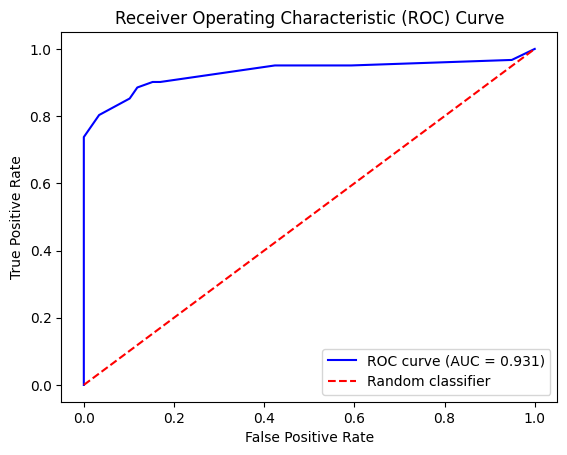

In [71]:
# Plot

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()